# 💳 Credit Risk Scoring — GiveMeSomeCredit

| Field | Detail |
|---|---|
| **Dataset** | GiveMeSomeCredit (Kaggle) |
| **Task** | Binary Classification — Predict loan default |
| **Target** | `SeriousDlqin2yrs` (0 = Good, 1 = Defaulted) |
| **Models** | Logistic Regression, Decision Tree, KNN, SVM, Naive Bayes, Random Forest, XGBoost, AdaBoost, Gradient Boosting, Bagging |

---
> ⚠️ **Instructions**: Run cells sequentially. Heavy training cells are marked with `⏳`. Ensure `data/cs-training.csv` exists before running.

## 0. 📦 Imports & Setup

In [44]:
import os
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.svm               import LinearSVC
from sklearn.naive_bayes       import GaussianNB
from sklearn.ensemble          import (RandomForestClassifier,
                                        AdaBoostClassifier,
                                        GradientBoostingClassifier,
                                        BaggingClassifier)
from sklearn.metrics           import (accuracy_score, precision_score,
                                        recall_score, f1_score,
                                        roc_auc_score, confusion_matrix,
                                        classification_report,
                                        ConfusionMatrixDisplay,
                                        RocCurveDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Output directories ──
PLOTS_DIR   = os.path.join('outputs', 'plots')
MODELS_DIR  = os.path.join('outputs', 'models')
REPORTS_DIR = os.path.join('outputs', 'reports')
for d in [PLOTS_DIR, MODELS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Helper ──
def save_fig(name):
    path = os.path.join(PLOTS_DIR, f'{name}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  ✓ Saved → {path}')

print('✅ Setup complete.')

✅ Setup complete.


## 1. 📂 Data Loading

In [45]:
DATA_PATH = 'cs-training.csv'
df = pd.read_csv(DATA_PATH, index_col=0)

print(f'Shape  : {df.shape}')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape  : (150000, 11)
Memory : 13.2 MB


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [46]:
print('Data Types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe().T.style.background_gradient(cmap='Blues')

Data Types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.000000,0.066840,0.249746,0.000000,0.000000,0.000000,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,150000.000000,6.048438,249.755371,0.000000,0.029867,0.154181,0.559046,50708.000000
age,150000.000000,52.295207,14.771866,0.000000,41.000000,52.000000,63.000000,109.000000
NumberOfTime30-59DaysPastDueNotWorse,150000.000000,0.421033,4.192781,0.000000,0.000000,0.000000,0.000000,98.000000
DebtRatio,150000.000000,353.005076,2037.818523,0.000000,0.175074,0.366508,0.868254,329664.000000
MonthlyIncome,120269.000000,6670.221237,14384.674215,0.000000,3400.000000,5400.000000,8249.000000,3008750.000000
NumberOfOpenCreditLinesAndLoans,150000.000000,8.452760,5.145951,0.000000,5.000000,8.000000,11.000000,58.000000
NumberOfTimes90DaysLate,150000.000000,0.265973,4.169304,0.000000,0.000000,0.000000,0.000000,98.000000
NumberRealEstateLoansOrLines,150000.000000,1.018240,1.129771,0.000000,0.000000,1.000000,2.000000,54.000000
NumberOfTime60-89DaysPastDueNotWorse,150000.000000,0.240387,4.155179,0.000000,0.000000,0.000000,0.000000,98.000000


## 2. 🔍 Exploratory Data Analysis (EDA)

### 2a. Class Distribution

  ✓ Saved → outputs\plots\01_class_distribution.png


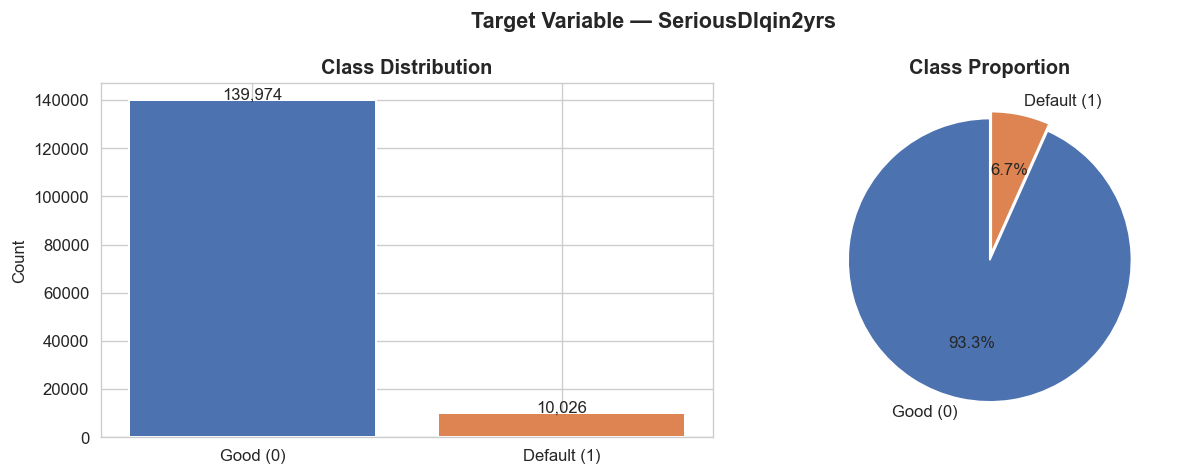


Imbalance ratio (Good:Default) = 14.0:1
→ Class imbalance present — will use class_weight="balanced" in models


In [47]:
TARGET = 'SeriousDlqin2yrs'
class_counts = df[TARGET].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(['Good (0)', 'Default (1)'], class_counts.values,
            color=['#4c72b0', '#dd8452'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=['Good (0)', 'Default (1)'],
            autopct='%1.1f%%', colors=['#4c72b0', '#dd8452'],
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Target Variable — SeriousDlqin2yrs', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('01_class_distribution')
plt.show()

imbalance_ratio = class_counts[0] / class_counts[1]
print(f'\nImbalance ratio (Good:Default) = {imbalance_ratio:.1f}:1')
print('→ Class imbalance present — will use class_weight="balanced" in models')

### 2b. Missing Value Analysis

Features with Missing Values:
                    Count  Percentage (%)
MonthlyIncome       29731           19.82
NumberOfDependents   3924            2.62
  ✓ Saved → outputs\plots\02_missing_values.png


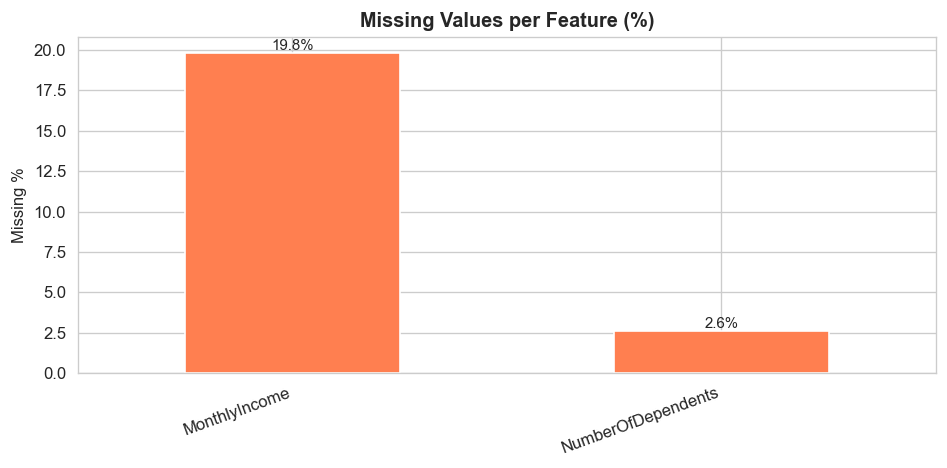

In [48]:
missing      = df.isnull().sum()
missing_pct  = (missing / len(df) * 100).round(2)
missing_df   = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df   = missing_df[missing_df['Count'] > 0].sort_values('Percentage (%)', ascending=False)

print('Features with Missing Values:')
print(missing_df)

if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Percentage (%)'].plot(kind='bar', color='coral', edgecolor='white', ax=ax)
    ax.set_title('Missing Values per Feature (%)', fontweight='bold')
    ax.set_ylabel('Missing %')
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.1f}%',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    save_fig('02_missing_values')
    plt.show()
else:
    print('No missing values found.')

### 2c. Correlation Heatmap

  ✓ Saved → outputs\plots\03_correlation_heatmap.png


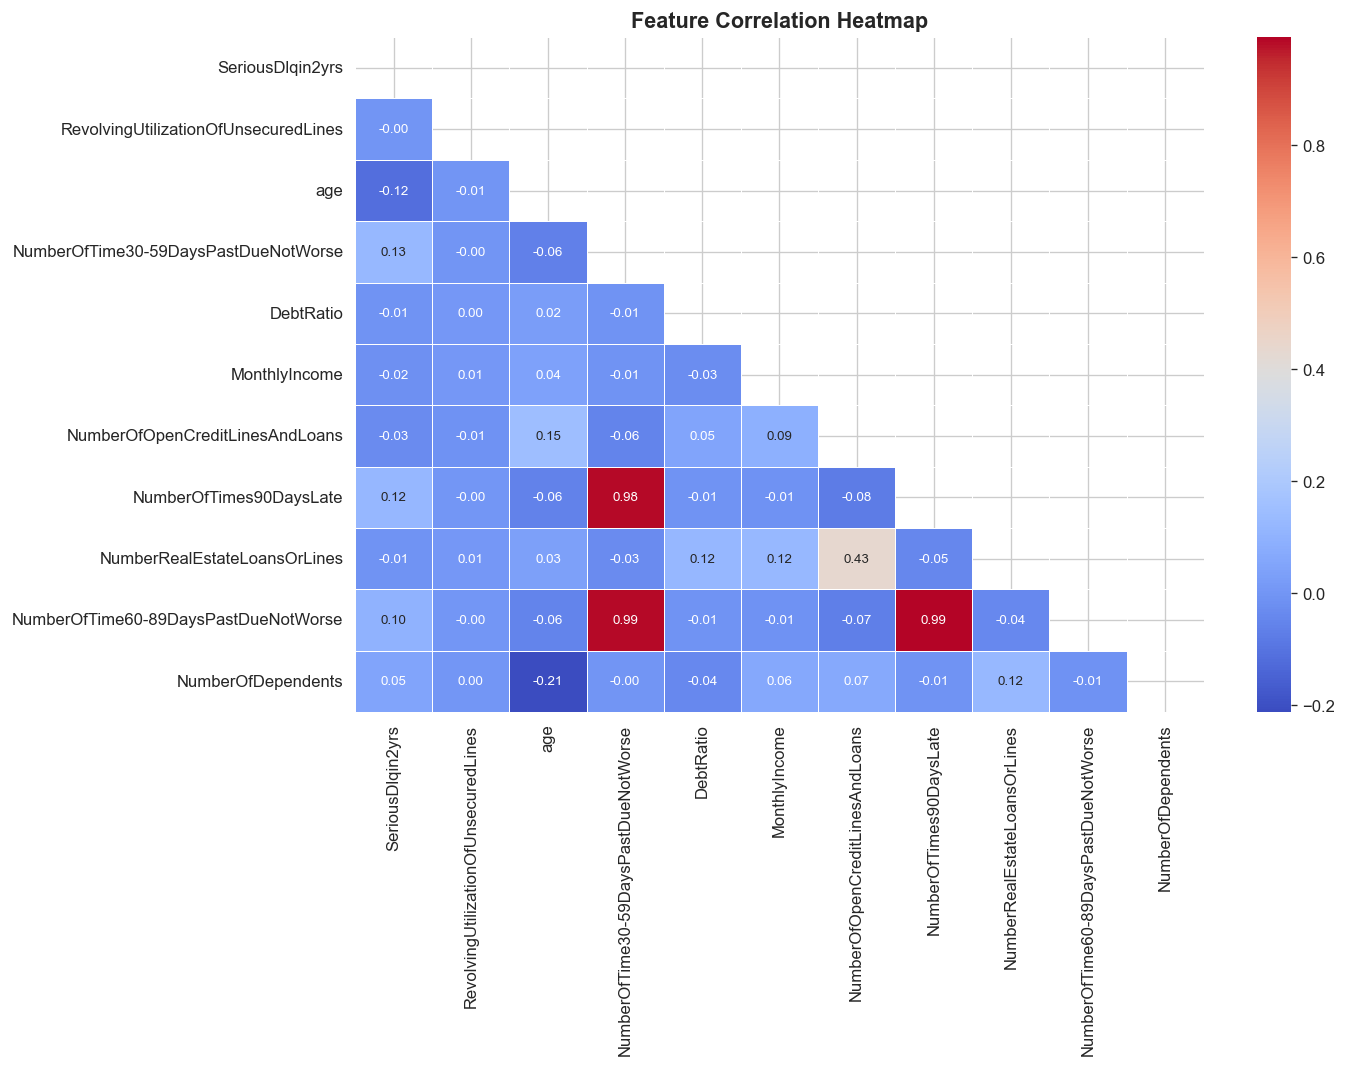


Top correlations with target:
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
age                                     0.115386
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
NumberOfOpenCreditLinesAndLoans         0.029669
Name: SeriousDlqin2yrs, dtype: float64


In [49]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))    # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, linecolor='white', ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('03_correlation_heatmap')
plt.show()

# Highest correlated pairs with target
print('\nTop correlations with target:')
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(6))

### 2d. Feature Distributions

  ✓ Saved → outputs\plots\04_feature_distributions.png


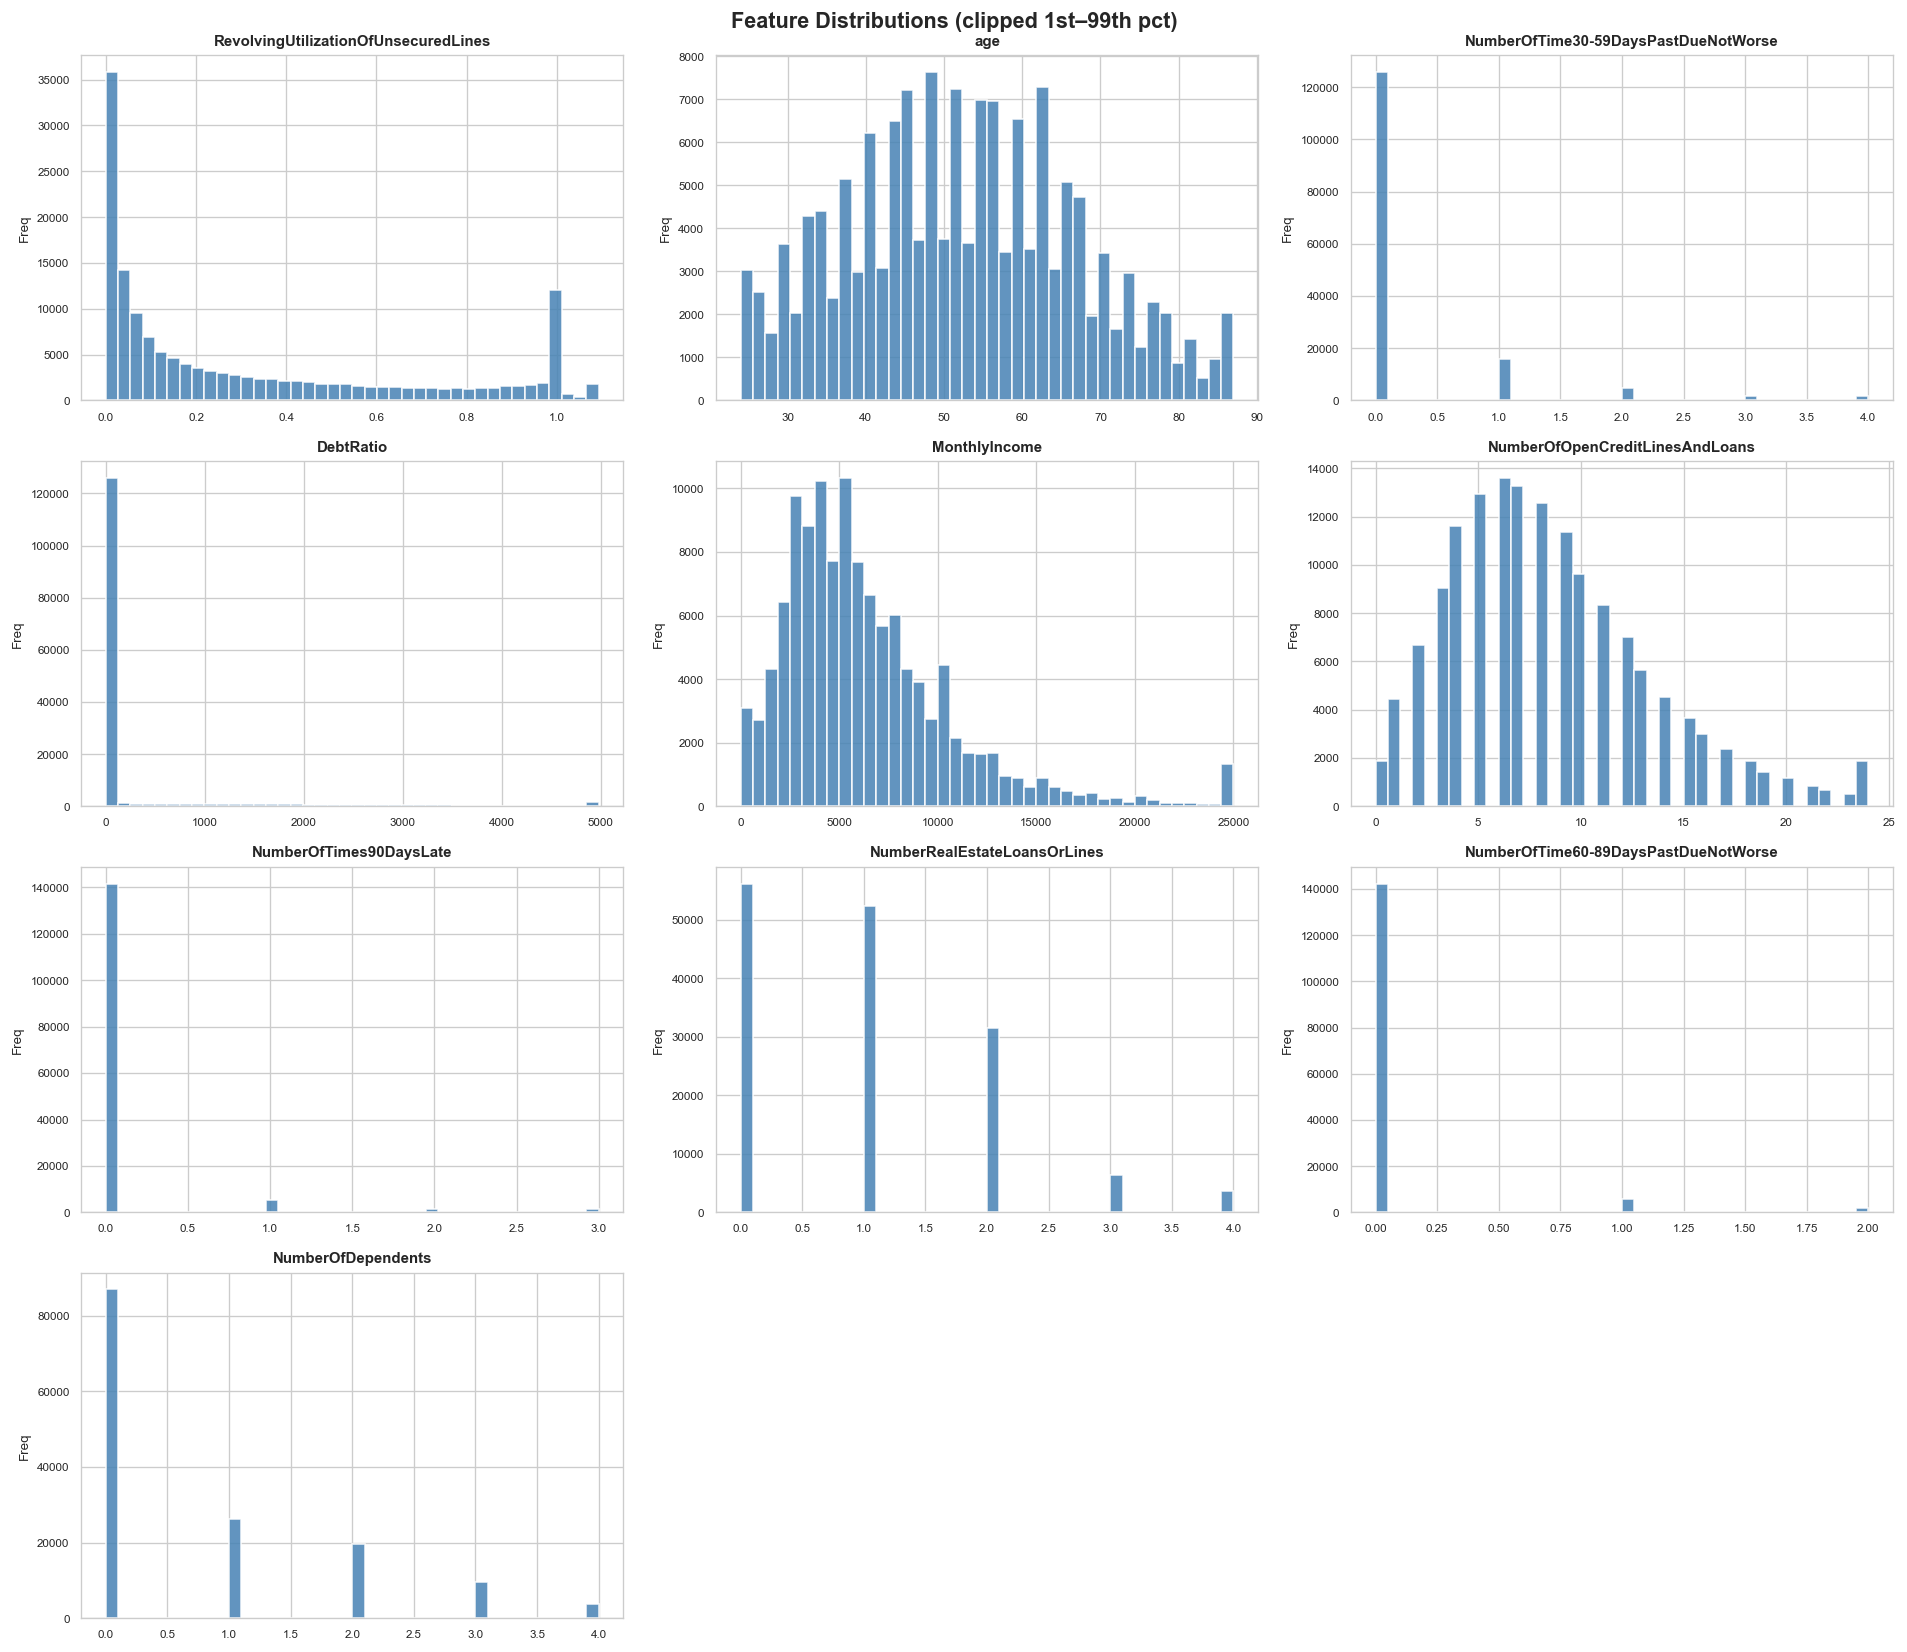

In [50]:
features = [c for c in df.columns if c != TARGET]
n_cols   = 3
n_rows   = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes      = axes.flatten()

for i, feat in enumerate(features):
    # Clip to 1st–99th percentile to reduce outlier distortion
    data_clipped = df[feat].clip(
        lower=df[feat].quantile(0.01),
        upper=df[feat].quantile(0.99)
    )
    axes[i].hist(data_clipped, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Freq', fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions (clipped 1st–99th pct)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('04_feature_distributions')
plt.show()

  ✓ Saved → outputs\plots\04b_boxplots_by_class.png


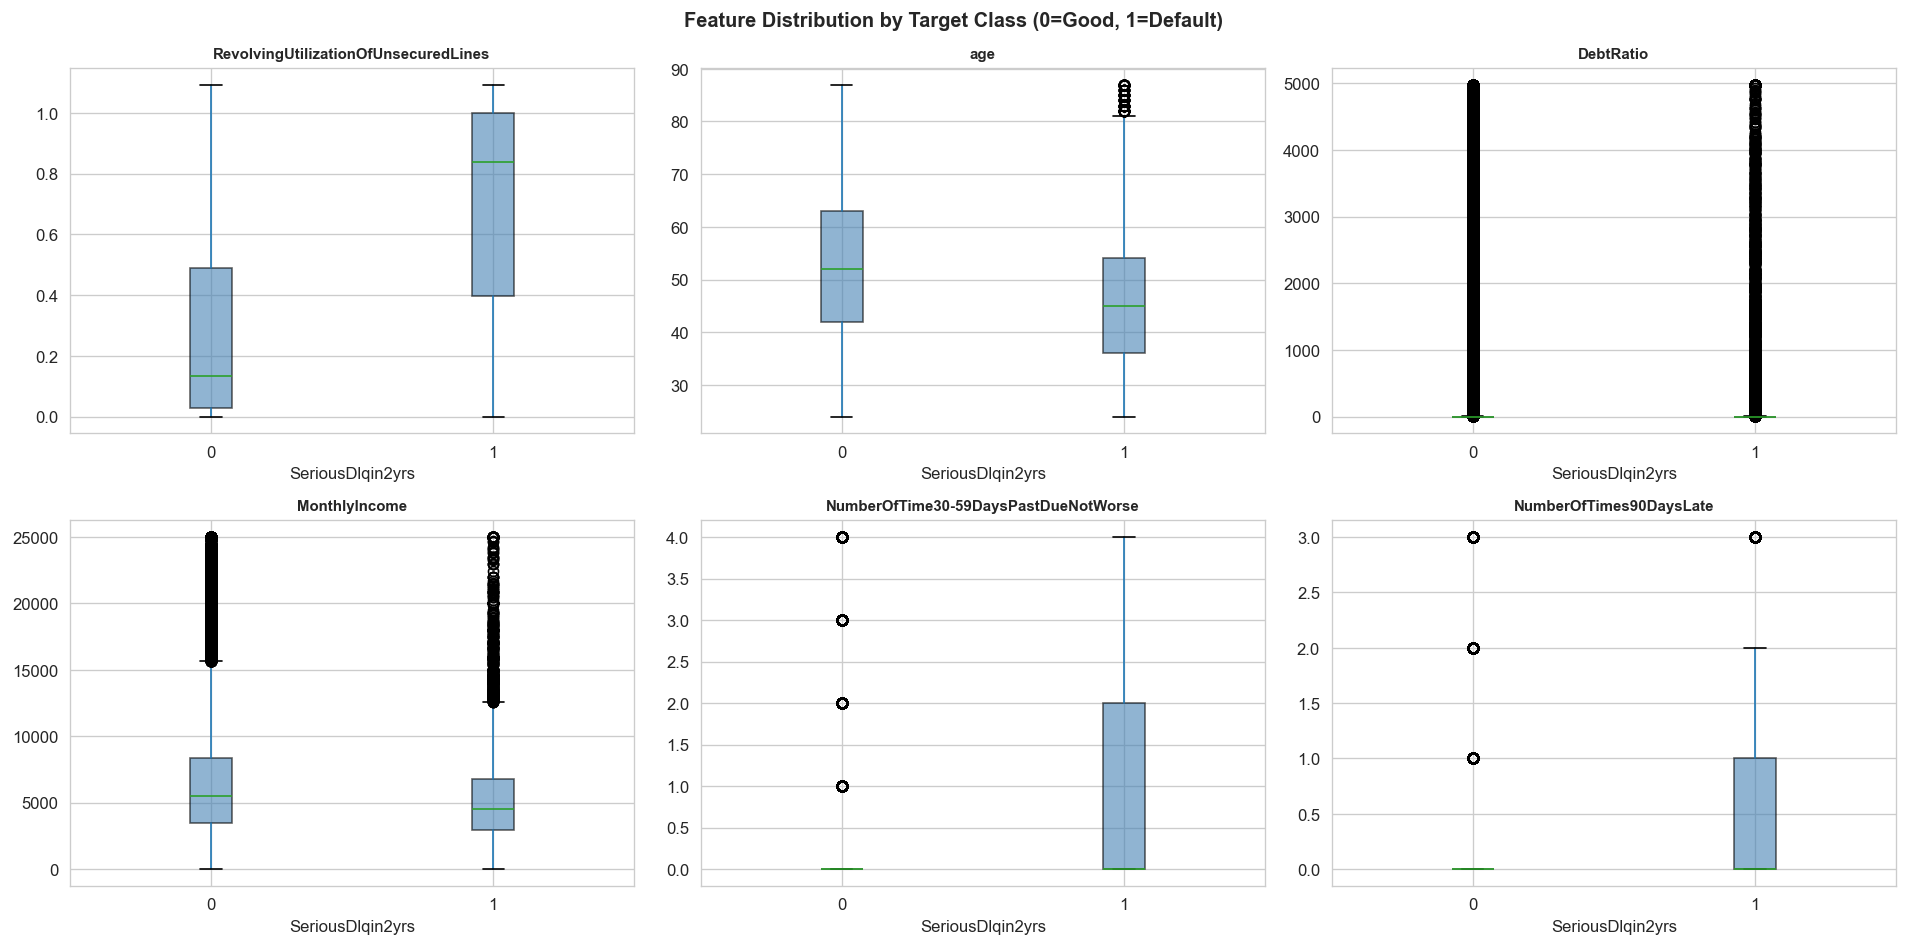

In [51]:
# ── Boxplots by target class (key features) ──
key_feats = ['RevolvingUtilizationOfUnsecuredLines', 'age',
             'DebtRatio', 'MonthlyIncome',
             'NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_feats):
    data_clipped = df[[feat, TARGET]].copy()
    data_clipped[feat] = data_clipped[feat].clip(
        lower=data_clipped[feat].quantile(0.01),
        upper=data_clipped[feat].quantile(0.99)
    )
    data_clipped.boxplot(column=feat, by=TARGET, ax=axes[i],
                         patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('SeriousDlqin2yrs')
    plt.sca(axes[i])

fig.suptitle('Feature Distribution by Target Class (0=Good, 1=Default)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('04b_boxplots_by_class')
plt.show()

## 3. 🔧 Data Preprocessing

In [52]:
# ── 3a. Drop duplicates ──
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed : {before - len(df)}')

# ── 3b. Impute missing values ──
# MonthlyIncome and NumberOfDependents have missing values → median imputation
for col in ['MonthlyIncome', 'NumberOfDependents']:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'Imputed "{col}" with median = {median_val}')

print(f'Missing values remaining : {df.isnull().sum().sum()}')

# ── 3c. Feature / Target ──
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(f'\nFeatures : {list(X.columns)}')
print(f'Samples  : {X.shape[0]:,}')

# ── 3d. Train-Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'\nTrain : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}')

# ── 3e. Feature Scaling ──
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.joblib'))
print('✓ Scaler fitted and saved.')

# ── Reduced sets for memory-heavy models ──
SMALL_N      = 20_000
X_tr_small   = X_train_sc[:SMALL_N]
y_tr_small   = y_train.iloc[:SMALL_N]
print(f'\nSubset for KNN/SVM : {SMALL_N:,} samples')

Duplicates removed : 609
Imputed "MonthlyIncome" with median = 5400.0
Imputed "NumberOfDependents" with median = 0.0
Missing values remaining : 33049

Features : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Samples  : 149,391

Train : 119,512  |  Test : 29,879
✓ Scaler fitted and saved.

Subset for KNN/SVM : 20,000 samples


## 4. 🤖 Classification Models

We define a reusable `evaluate()` function and train all 10 models.

In [53]:
results = []   # metric dicts
trained = {}   # name → fitted model

def evaluate(name, model, X_tr, y_tr, X_te, y_te, use_proba=True):
    """Fit model, compute metrics, save classification report."""
    print(f'▶ Training {name} ...', end=' ', flush=True)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if use_proba and hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_te)
    else:
        y_prob = y_pred

    auc = roc_auc_score(y_te, y_prob)
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC'  : auc,
    }
    print(f'Done  |  Acc={metrics["Accuracy"]:.4f}  AUC={auc:.4f}')

    report = classification_report(y_te, y_pred, target_names=['Good (0)', 'Default (1)'])
    with open(os.path.join(REPORTS_DIR, f'{name.replace(" ","_")}_report.txt'), 'w') as f:
        f.write(f'Model: {name}\n\n{report}')

    return metrics, model, y_pred, y_prob

print('evaluate() function ready.')

evaluate() function ready.


In [54]:
# Fix invalid values before training

import numpy as np

# Replace infinite values
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc = np.nan_to_num(X_test_sc, nan=0.0, posinf=0.0, neginf=0.0)

print("NaN in train:", np.isnan(X_train_sc).sum())
print("NaN in test :", np.isnan(X_test_sc).sum())

print("Infinite in train:", np.isinf(X_train_sc).sum())
print("Infinite in test :", np.isinf(X_test_sc).sum())

print("Cleanup done.")

NaN in train: 0
NaN in test : 0
Infinite in train: 0
Infinite in test : 0
Cleanup done.


### 4a. Baseline Models

In [55]:
# ── Logistic Regression ──
m, model, _, _ = evaluate('Logistic Regression',
    LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=42, n_jobs=-1),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['Logistic Regression'] = model

▶ Training Logistic Regression ... Done  |  Acc=0.7944  AUC=0.8037


In [56]:
# ── Decision Tree ──
m, model, _, _ = evaluate('Decision Tree',
    DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['Decision Tree'] = model

▶ Training Decision Tree ... Done  |  Acc=0.7904  AUC=0.8360


In [57]:
# KNN cleanup

X_tr_small = np.nan_to_num(X_tr_small)
X_test_sc = np.nan_to_num(X_test_sc)

X_tr_small = X_tr_small.astype(np.float64)
X_test_sc = X_test_sc.astype(np.float64)

print("KNN data cleaned.")

KNN data cleaned.


In [58]:
# ── KNN (⚠️ uses reduced sample for memory efficiency) ──
m, model, _, _ = evaluate('KNN',
    KNeighborsClassifier(n_neighbors=9),
    X_tr_small, y_tr_small, X_test_sc, y_test)
results.append(m); trained['KNN'] = model

▶ Training KNN ... Done  |  Acc=0.9344  AUC=0.6949


In [59]:
# ── SVM — LinearSVC (⚠️ uses reduced sample) ──
m, model, _, _ = evaluate('SVM (LinearSVC)',
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    X_tr_small, y_tr_small, X_test_sc, y_test, use_proba=False)
results.append(m); trained['SVM (LinearSVC)'] = model

▶ Training SVM (LinearSVC) ... Done  |  Acc=0.6447  AUC=0.7045


In [60]:
# ── Naive Bayes ──
m, model, _, _ = evaluate('Naive Bayes',
    GaussianNB(),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['Naive Bayes'] = model

▶ Training Naive Bayes ... Done  |  Acc=0.9321  AUC=0.7027


### 4b. ⏳ Ensemble Models (may take a few minutes)

In [61]:
# ── Random Forest ──
m, model, _, _ = evaluate('Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=10,
                           class_weight='balanced', n_jobs=-1, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['Random Forest'] = model

▶ Training Random Forest ... Done  |  Acc=0.8179  AUC=0.8577


In [62]:
# ── XGBoost ──
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
m, model, _, _ = evaluate('XGBoost',
    XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                  scale_pos_weight=scale_pos, eval_metric='logloss',
                  tree_method='hist', n_jobs=-1, random_state=42, verbosity=0),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['XGBoost'] = model

▶ Training XGBoost ... Done  |  Acc=0.8214  AUC=0.8558


In [63]:
# ── AdaBoost ──
m, model, _, _ = evaluate('AdaBoost',
    AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['AdaBoost'] = model

▶ Training AdaBoost ... Done  |  Acc=0.9352  AUC=0.8562


In [64]:
# ── Gradient Boosting ──
m, model, _, _ = evaluate('Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, max_depth=5,
                               learning_rate=0.1, subsample=0.8, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['Gradient Boosting'] = model

▶ Training Gradient Boosting ... Done  |  Acc=0.9365  AUC=0.8640


In [65]:
# ── Bagging ──
m, model, _, _ = evaluate('Bagging',
    BaggingClassifier(n_estimators=50, max_samples=0.8,
                      max_features=0.8, n_jobs=-1, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test)
results.append(m); trained['Bagging'] = model

▶ Training Bagging ... Done  |  Acc=0.9363  AUC=0.8367


## 5. 📊 Results & Model Comparison

In [66]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)

# Styled table
results_df.to_csv(os.path.join(REPORTS_DIR, 'model_comparison.csv'))
results_df.style \
    .background_gradient(cmap='YlOrRd', subset=['ROC-AUC', 'F1-Score']) \
    .format('{:.4f}') \
    .set_caption('Model Comparison Table — Sorted by ROC-AUC')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.9365,0.5720,0.2103,0.3075,0.8640
Random Forest,0.8179,0.2309,0.7368,0.3516,0.8577
AdaBoost,0.9352,0.5462,0.1948,0.2872,0.8562
XGBoost,0.8214,0.2337,0.7308,0.3542,0.8558
Bagging,0.9363,0.5865,0.1693,0.2628,0.8367
Decision Tree,0.7904,0.2076,0.7557,0.3257,0.8360
Logistic Regression,0.7944,0.1939,0.6548,0.2992,0.8037
SVM (LinearSVC),0.6447,0.1158,0.6484,0.1965,0.7045
Naive Bayes,0.9321,0.4177,0.0330,0.0611,0.7027


  ✓ Saved → outputs\plots\05_model_comparison.png


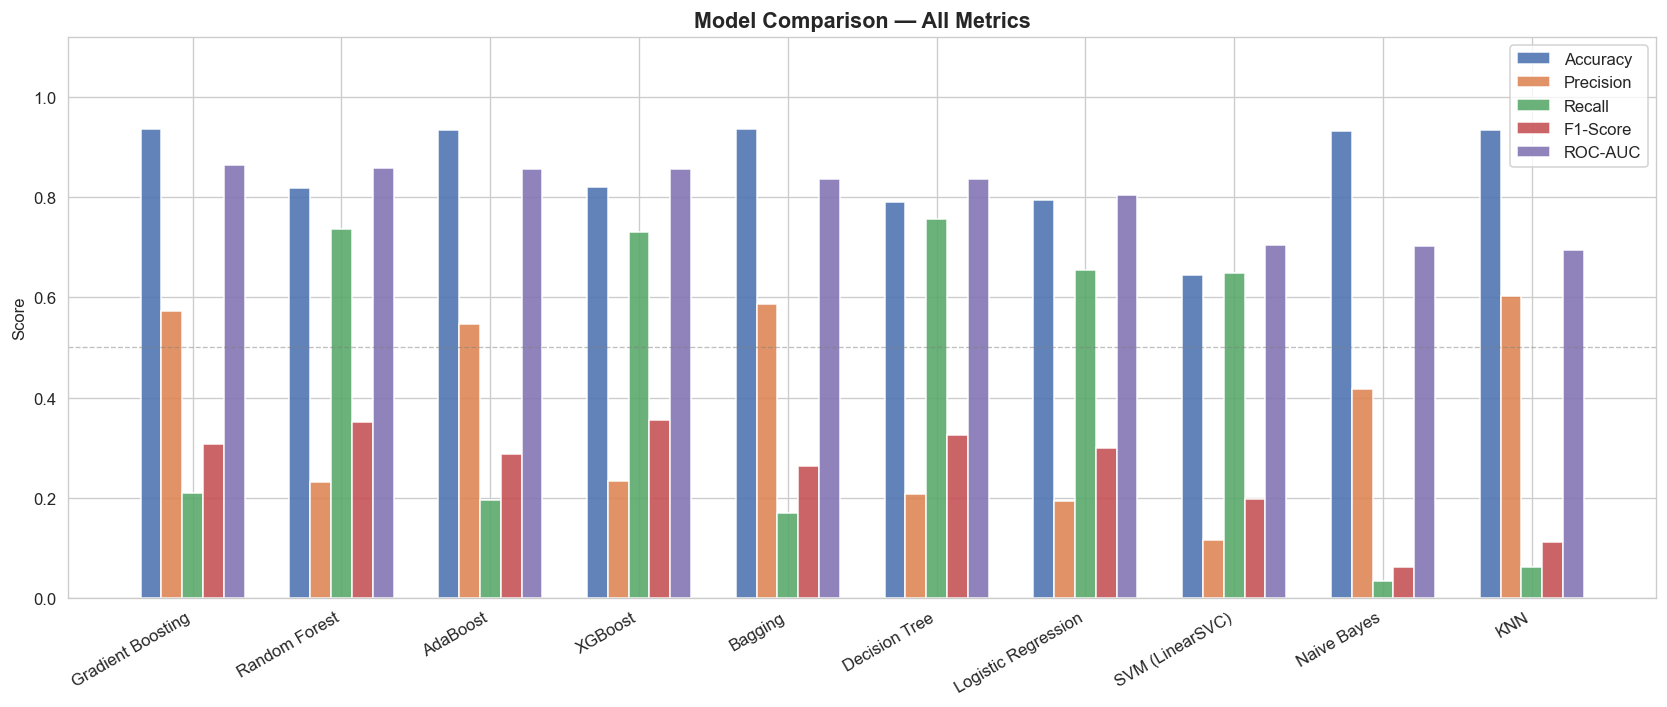

In [67]:
# ── Multi-metric bar chart ──
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x      = np.arange(len(results_df))
width  = 0.14
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b2']

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width,
           label=metric, color=colors[i], alpha=0.88)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
save_fig('05_model_comparison')
plt.show()

  ✓ Saved → outputs\plots\06_roc_auc_comparison.png


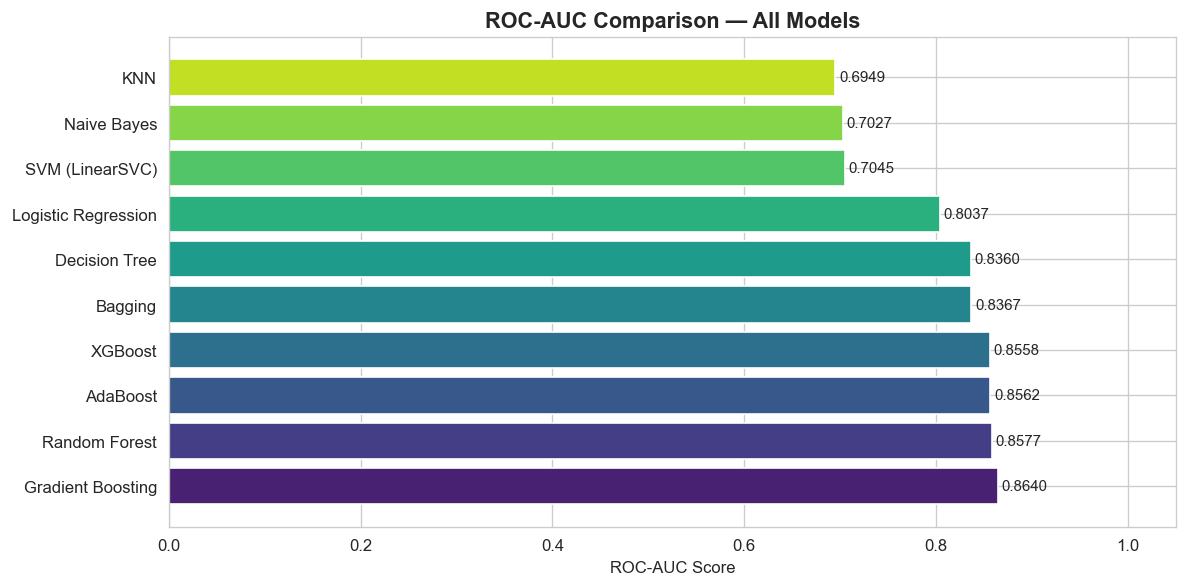

In [68]:
# ── ROC-AUC horizontal bar ──
fig, ax = plt.subplots(figsize=(10, 5))
colors_roc = sns.color_palette('viridis', len(results_df))
bars = ax.barh(results_df.index, results_df['ROC-AUC'],
               color=colors_roc, edgecolor='white')
ax.set_xlabel('ROC-AUC Score')
ax.set_title('ROC-AUC Comparison — All Models', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, results_df['ROC-AUC']):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
save_fig('06_roc_auc_comparison')
plt.show()

## 6. 🏆 Best Model — Deep Analysis

In [69]:
best_name  = results_df['ROC-AUC'].idxmax()
best_model = trained[best_name]
print(f'🏆 Best Model : {best_name}')
print(f'   ROC-AUC   : {results_df.loc[best_name, "ROC-AUC"]:.4f}')
print(f'   Accuracy  : {results_df.loc[best_name, "Accuracy"]:.4f}')
print(f'   F1-Score  : {results_df.loc[best_name, "F1-Score"]:.4f}')

use_small_models = {'KNN', 'SVM (LinearSVC)'}
X_tr_b = X_tr_small if best_name in use_small_models else X_train_sc
y_tr_b = y_tr_small if best_name in use_small_models else y_train

best_model.fit(X_tr_b, y_tr_b)
y_pred_best = best_model.predict(X_test_sc)

if hasattr(best_model, 'predict_proba'):
    y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]
elif hasattr(best_model, 'decision_function'):
    y_prob_best = best_model.decision_function(X_test_sc)
else:
    y_prob_best = y_pred_best

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Good (0)', 'Default (1)']))

🏆 Best Model : Gradient Boosting
   ROC-AUC   : 0.8640
   Accuracy  : 0.9365
   F1-Score  : 0.3075

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.95      0.99      0.97     27877
 Default (1)       0.57      0.21      0.31      2002

    accuracy                           0.94     29879
   macro avg       0.76      0.60      0.64     29879
weighted avg       0.92      0.94      0.92     29879



  ✓ Saved → outputs\plots\07_08_best_model_cm_roc.png


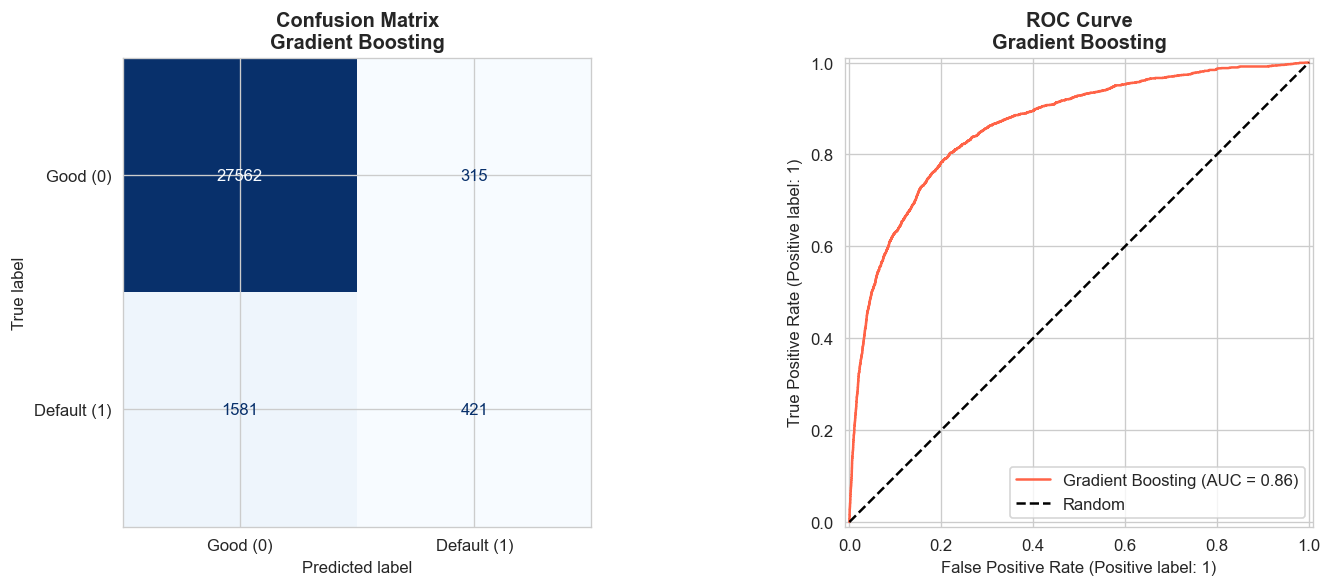

✓ Best model saved → outputs/models/best_model.joblib


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Good (0)', 'Default (1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

# ROC Curve
if not isinstance(y_prob_best[0], (int, np.integer)):
    RocCurveDisplay.from_predictions(y_test, y_prob_best,
                                     name=best_name, ax=axes[1], color='tomato')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title(f'ROC Curve\n{best_name}', fontweight='bold')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'ROC not available\n(no probabilities)',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
save_fig('07_08_best_model_cm_roc')
plt.show()

# Save best model
joblib.dump(best_model, os.path.join(MODELS_DIR, 'best_model.joblib'))
print(f'✓ Best model saved → outputs/models/best_model.joblib')

### 6b. Confusion Matrices — All Models

  ✓ Saved → outputs\plots\10_all_confusion_matrices.png


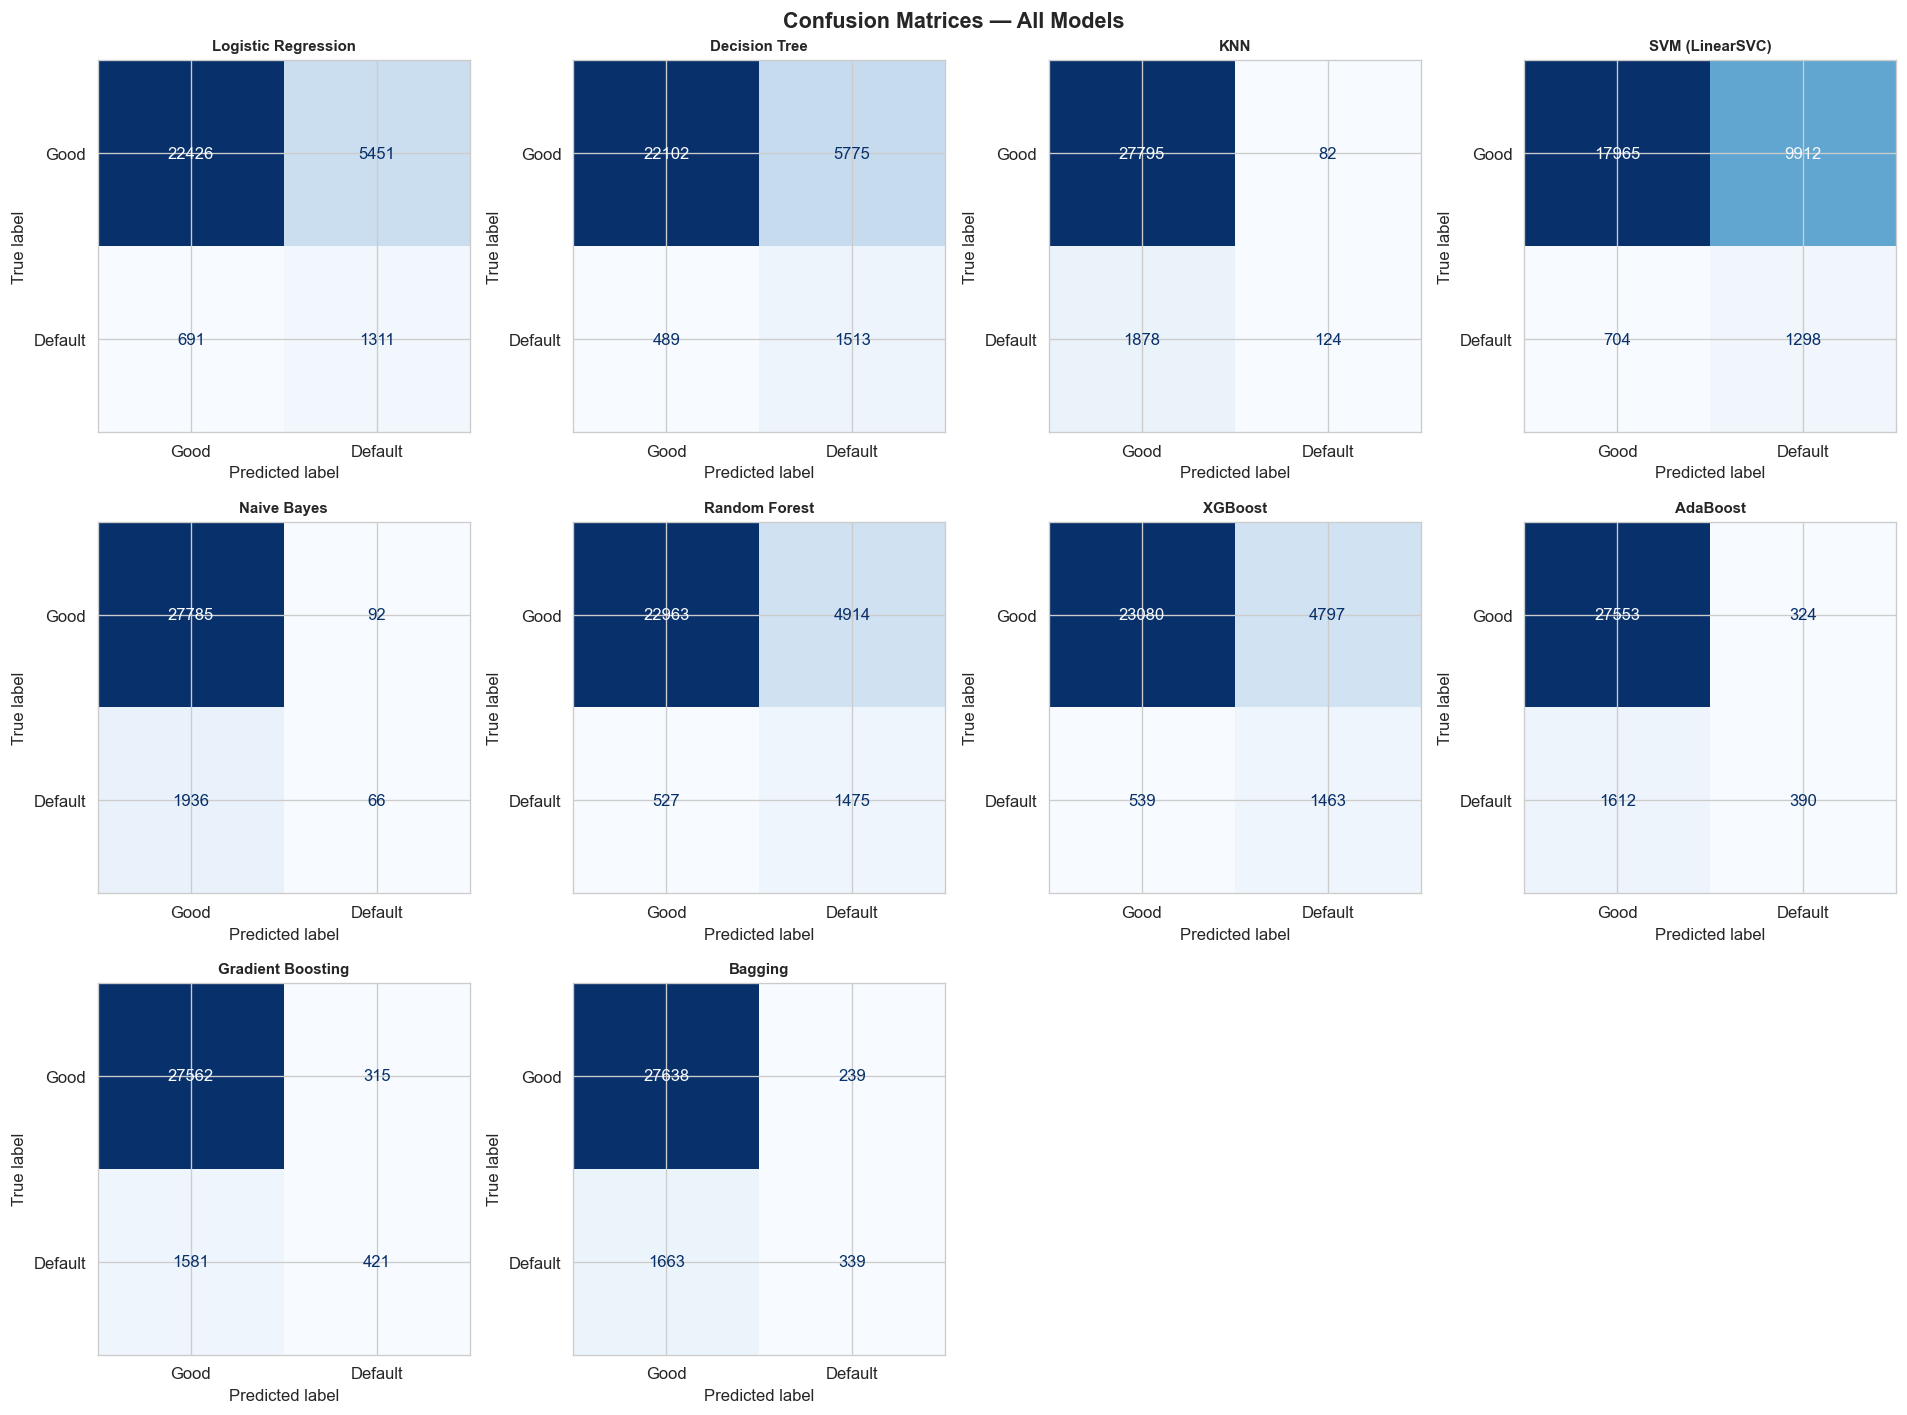

In [71]:
model_names = list(trained.keys())
n_cols      = 4
n_rows      = int(np.ceil(len(model_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes      = axes.flatten()

for i, name in enumerate(model_names):
    use_small = name in use_small_models
    X_tr_i = X_tr_small if use_small else X_train_sc
    y_tr_i = y_tr_small if use_small else y_train
    trained[name].fit(X_tr_i, y_tr_i)
    y_pred_i = trained[name].predict(X_test_sc)
    cm_i = confusion_matrix(y_test, y_pred_i)
    ConfusionMatrixDisplay(cm_i, display_labels=['Good', 'Default']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('10_all_confusion_matrices')
plt.show()

## 7. 🌳 Feature Importance (Tree-Based Models)

  ✓ Saved → outputs\plots\09_feature_importances.png


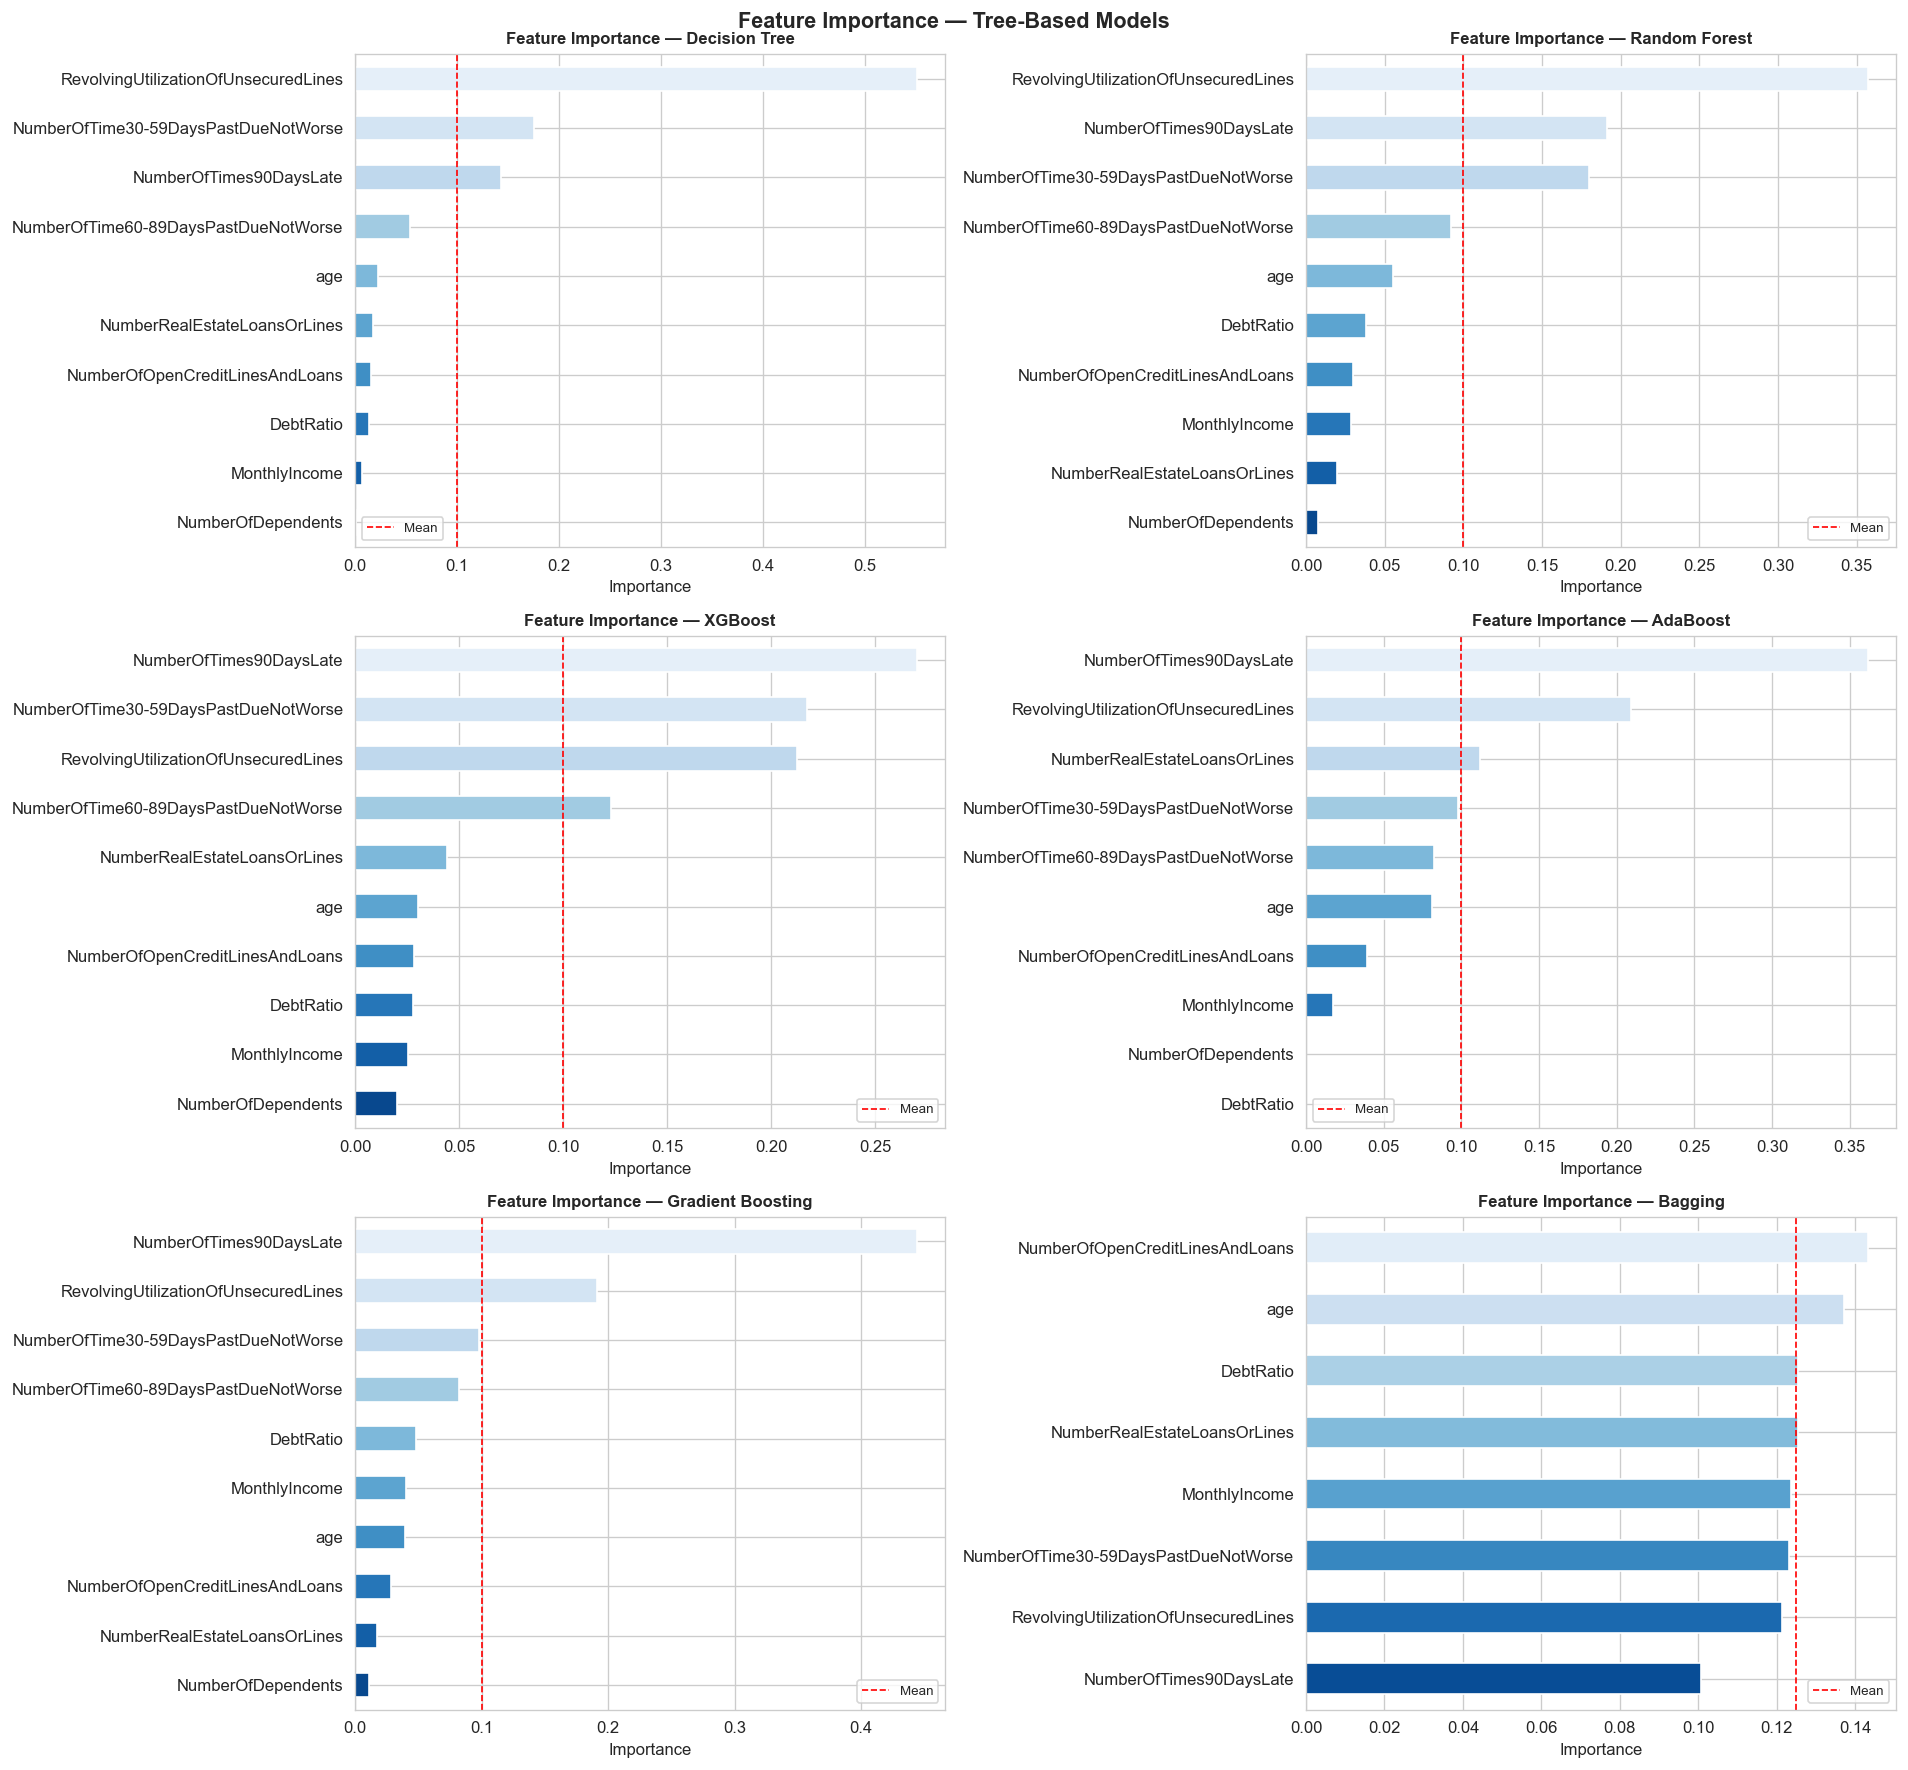

In [74]:
feature_names  = list(X.columns)
treefeature_names = list(X.columns)

tree_models = [
    'Decision Tree',
    'Random Forest',
    'XGBoost',
    'AdaBoost',
    'Gradient Boosting',
    'Bagging'
]

n_cols = 2
n_rows = int(np.ceil(len(tree_models) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, name in enumerate(tree_models):

    model = trained[name]

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

    elif hasattr(model, 'estimators_'):
        try:
            importances = np.mean(
                [est.feature_importances_ for est in model.estimators_],
                axis=0
            )

        except AttributeError:
            axes[i].set_title(f'{name} — N/A')
            continue

    else:
        axes[i].set_title(f'{name} — N/A')
        continue

    # Safe feature importance handling
    min_len = min(len(importances), len(feature_names))

    fi_series = pd.Series(
        importances[:min_len],
        index=feature_names[:min_len]
    ).sort_values()

    colors_fi = sns.color_palette('Blues_r', len(fi_series))

    fi_series.plot(
        kind='barh',
        ax=axes[i],
        color=colors_fi,
        edgecolor='white'
    )

    axes[i].set_title(
        f'Feature Importance — {name}',
        fontsize=10,
        fontweight='bold'
    )

    axes[i].set_xlabel('Importance')

    axes[i].axvline(
        fi_series.mean(),
        color='red',
        linestyle='--',
        linewidth=1,
        label='Mean'
    )

    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Feature Importance — Tree-Based Models',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

save_fig('09_feature_importances')

plt.show()

## 8. ✅ Summary & Conclusion

In [75]:
print('='*60)
print('  CREDIT RISK SCORING — FINAL SUMMARY')
print('='*60)
print(f'\n  Best Model  : {best_name}')
print(f'  ROC-AUC    : {results_df.loc[best_name, "ROC-AUC"]:.4f}')
print(f'  Accuracy   : {results_df.loc[best_name, "Accuracy"]:.4f}')
print(f'  Precision  : {results_df.loc[best_name, "Precision"]:.4f}')
print(f'  Recall     : {results_df.loc[best_name, "Recall"]:.4f}')
print(f'  F1-Score   : {results_df.loc[best_name, "F1-Score"]:.4f}')
print()
print('  Outputs saved:')
print(f'    Plots   → outputs/plots/ ({len(os.listdir(PLOTS_DIR))} files)')
print(f'    Models  → outputs/models/ ({len(os.listdir(MODELS_DIR))} files)')
print(f'    Reports → outputs/reports/ ({len(os.listdir(REPORTS_DIR))} files)')
print()
print('  Full results table:')
print(results_df.to_string(float_format='{:.4f}'.format))
print('='*60)

  CREDIT RISK SCORING — FINAL SUMMARY

  Best Model  : Gradient Boosting
  ROC-AUC    : 0.8640
  Accuracy   : 0.9365
  Precision  : 0.5720
  Recall     : 0.2103
  F1-Score   : 0.3075

  Outputs saved:
    Plots   → outputs/plots/ (10 files)
    Models  → outputs/models/ (2 files)
    Reports → outputs/reports/ (11 files)

  Full results table:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Gradient Boosting      0.9365     0.5720  0.2103    0.3075   0.8640
Random Forest          0.8179     0.2309  0.7368    0.3516   0.8577
AdaBoost               0.9352     0.5462  0.1948    0.2872   0.8562
XGBoost                0.8214     0.2337  0.7308    0.3542   0.8558
Bagging                0.9363     0.5865  0.1693    0.2628   0.8367
Decision Tree          0.7904     0.2076  0.7557    0.3257   0.8360
Logistic Regression    0.7944     0.1939  0.6548    0.2992   0.8037
SVM (LinearSVC)        0.6447     0.1158  